<a href="https://colab.research.google.com/github/Sushmitha2375/Student-Performance-Prediction-/blob/main/Student_Performance_Prediction_(Regression)_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the necessary libraries that are required for the analysis of the data, for building the models , and visualizations


In [14]:
#import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

The dataset is uploaded into Google Colab for further processing

In [12]:
#import the file
from google.colab import files
uploaded = files.upload()

Saving archive (25).zip to archive (25) (1).zip


In this step extraction of the dataset from the ZIP file so it can be used for analysis

In [9]:
#unzip the file
import zipfile
import os
zip_path = "archive (25).zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")
print(os.listdir("data"))

['StudentsPerformance.csv']


Reads dataset into DataFrame df.

In [10]:
import pandas as pd
df = pd.read_csv("data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Helps understand dataset before preprocessing.
shape ,info, describe

In [16]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Checked for the missing values using isnull().sum() and there were no missing values

In [17]:
#check for the missing values
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


Used a boxplot to detect outliers the outliers

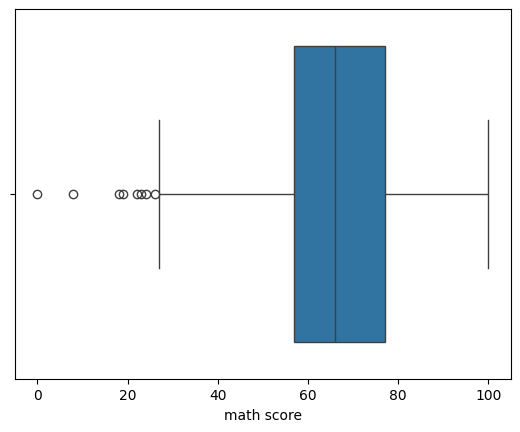

In [18]:
#for the outlier detection
sns.boxplot(x=df["math score"])
plt.show()

Created TotalScore to capture overall performance and improve prediction

In [19]:
#to calculate the overall perforamnce
df["TotalScore"] = df["math score"] + df["reading score"] + df["writing score"]

In [53]:
df = pd.get_dummies(df, drop_first=True)


In [54]:
#target value
X = df.drop("math score", axis=1)
y = df["math score"]

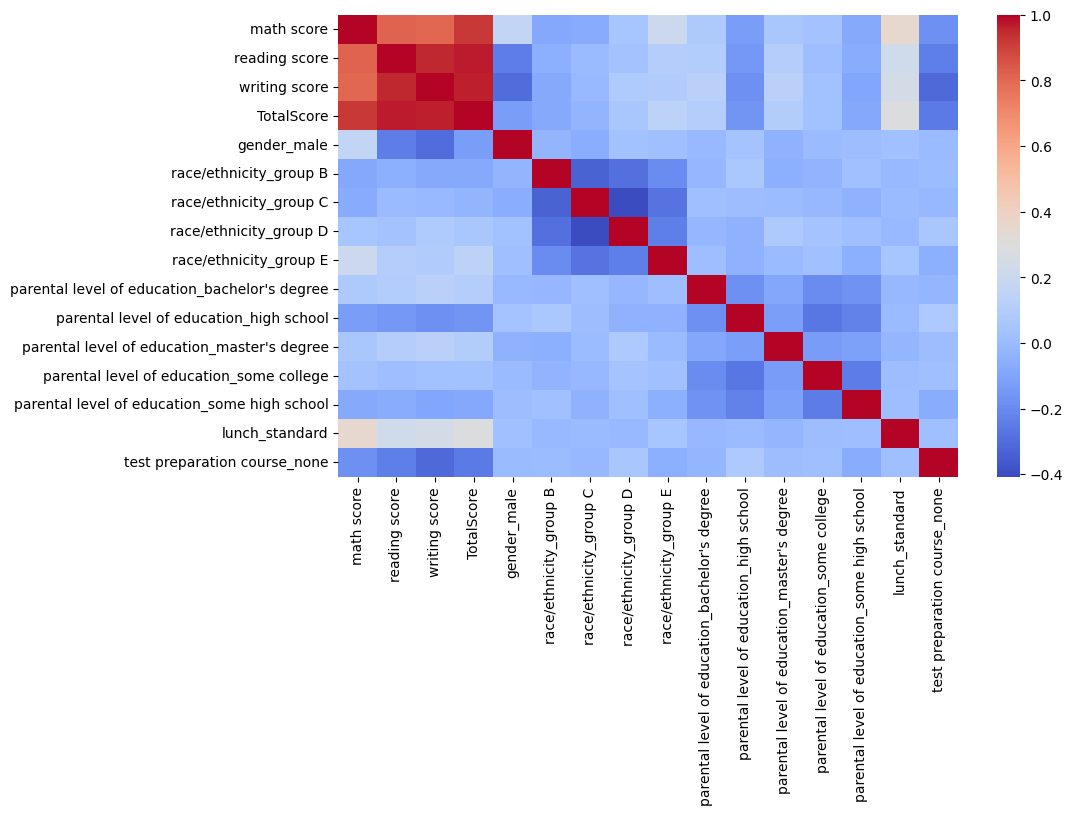

In [58]:
#before training
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

The dataset was split into training and testing sets using train_test_split

In [23]:
#train the model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 15)
Test shape: (200, 15)


training linear regression model

In [30]:
#train the linear regressor model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model_pred=model.predict(X_test)

training the random forest model

In [33]:
#train the random forest model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)
model_pred=model.predict(X_test)

training the gradient boosting model

In [34]:
#train the gradient boosting model
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()
model.fit(X_train, y_train)
model_pred=model.predict(X_test)

In [38]:
y_pred = model.predict(X_test)

Model performance was evaluated using RMSE and R² Score. The model showed good accuracy with low RMSE and high R²

In [39]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

RMSE: 3.2462744897886355
R2 Score: 0.9566928275066637


A comparison table was created to evaluate model performance using RMSE and R² Score. Random Forest performed best.

In [37]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,6.909104e-14,1.000000
1,Random Forest,2.897057e+00,0.965509
2,Gradient Boosting,3.240794e+00,0.956839


A scatter plot was used to compare actual and predicted values. Most points lie close to the diagonal line, showing good model performance

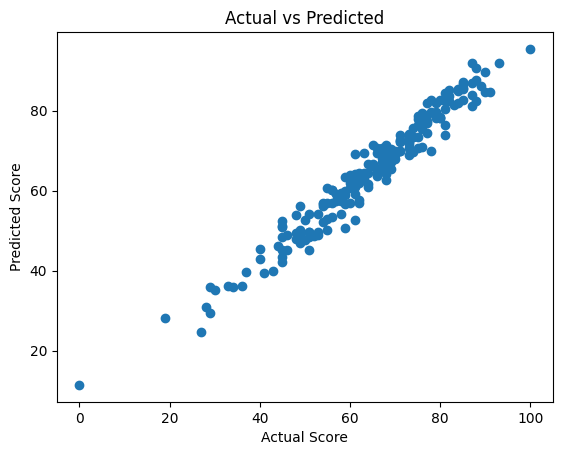

In [43]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
plt.show()

Used a histogram to understand score distribution where most scores were in the mid range

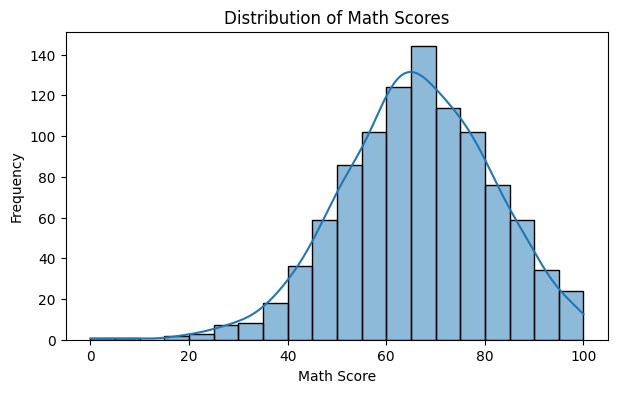

In [46]:
plt.figure(figsize=(7,4))
sns.histplot(df["math score"], kde=True, bins=20)
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

correlation heatmap was used to analyze relationships between variables. Reading and writing scores showed strong positive correlation with math score

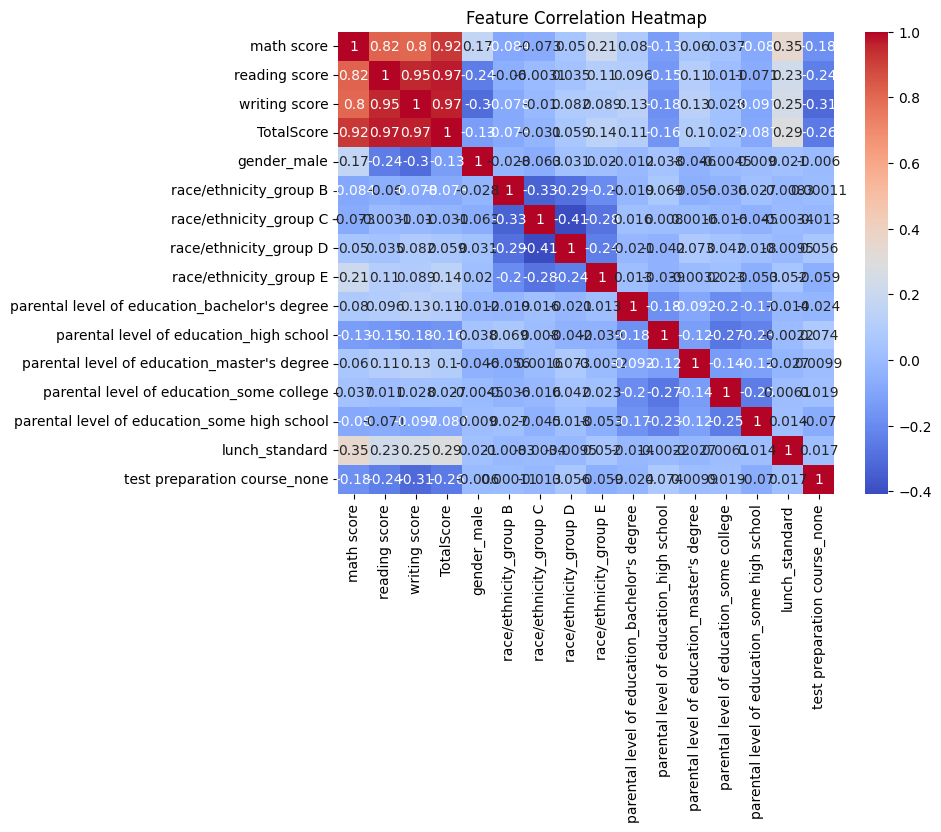

In [49]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()